In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score, confusion_matrix, classification_report

import sys 
sys.path.insert(0, r"C:\Users\jcmar\my_files\SportsBetting\BettingStrategy\ModelStrategy")
from LogisticRegression.get_train_test import TrainTestBuilder  

In [2]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\training_data\entire_odds_stats_2026-03-09.csv'
df_model = pd.read_csv(fp)

df_model['math_red'] = df_model['math_red'].astype('category')
df_model['math_blue'] = df_model['math_blue'].astype('category')

non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus', 'close1_blue','close1_red', 'close2_blue', 'close2_red', 'weight_class'
] 

# selected_feats = [
#                   'proba_fair_open_diff', 'reach_diff', 
#                   'td_landed_pm_red', 'td_landed_pm_blue', 'ratio_control_red', 'ratio_control_blue', 'ratio_td_red', 'ratio_td_blue', 
#                   'adjusted_sig_str_blue', 'adjusted_sig_str_red', 
#                   'sig_str_absorbed_total_diff', 
#                   'sig_str_defense_pct_diff', 'ratio_sig_str_red', 'ratio_sig_str_blue', 'kd_pm_diff', 
                    
#                   'win_pct_red', 'win_pct_blue', 
#                   'win_streak_diff', 'lose_streak_diff',
#                   'elo_red', 'elo_blue', 'age_red', 'age_blue',
#                   ]

selected_feats = [
                  'proba_fair_open_diff', 'reach_diff', 
                  
                  'sub_pct_red', 'sub_pct_blue',
                  'adjusted_td_red', 'adjusted_td_blue',
                  'ratio_control_red', 'ratio_control_blue', 'ratio_td_red', 'ratio_td_blue', 
                  
                  'sig_str_absorbed_pm_red', 'sig_str_absorbed_pm_blue', 
                  'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue',
                  'adjusted_sig_str_blue', 'adjusted_sig_str_red', 

                  'opp_age_red', 'opp_age_blue', 
                  
                  'ratio_sig_str_red', 'ratio_sig_str_blue', 'sig_str_defense_pct_red', 'sig_str_defense_pct_blue',
                  
                  'sig_str_absorbed_total_red',  'sig_str_absorbed_total_blue',
                    
                    'elo_pred', 'kd_pm_diff', 
                  'ko_losses_red', 'ko_losses_blue',
                    
                  'win_pct_red', 'win_pct_blue',
                  'win_streak_diff', 'lose_streak_diff',
                  'elo_red', 'elo_blue', 'age_red', 'age_blue'
                  ]



y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(selected_feats, outlier_dict=None)



Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: []
Numerical columns: ['proba_fair_open_diff', 'reach_diff', 'sub_pct_red', 'sub_pct_blue', 'adjusted_td_red', 'adjusted_td_blue', 'ratio_control_red', 'ratio_control_blue', 'ratio_td_red', 'ratio_td_blue', 'sig_str_absorbed_pm_red', 'sig_str_absorbed_pm_blue', 'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue', 'adjusted_sig_str_blue', 'adjusted_sig_str_red', 'opp_age_red', 'opp_age_blue', 'ratio_sig_str_red', 'ratio_sig_str_blue', 'sig_str_defense_pct_red', 'sig_str_defense_pct_blue', 'sig_str_absorbed_total_red', 'sig_str_absorbed_total_blue', 'elo_pred', 'kd_pm_diff', 'ko_losses_red', 'ko_losses_blue', 'win_pct_red', 'win_pct_blue', 'win_streak_diff', 'lose_streak_diff', 'elo_red', 'elo_blue', 'age_red', 'age_blue']


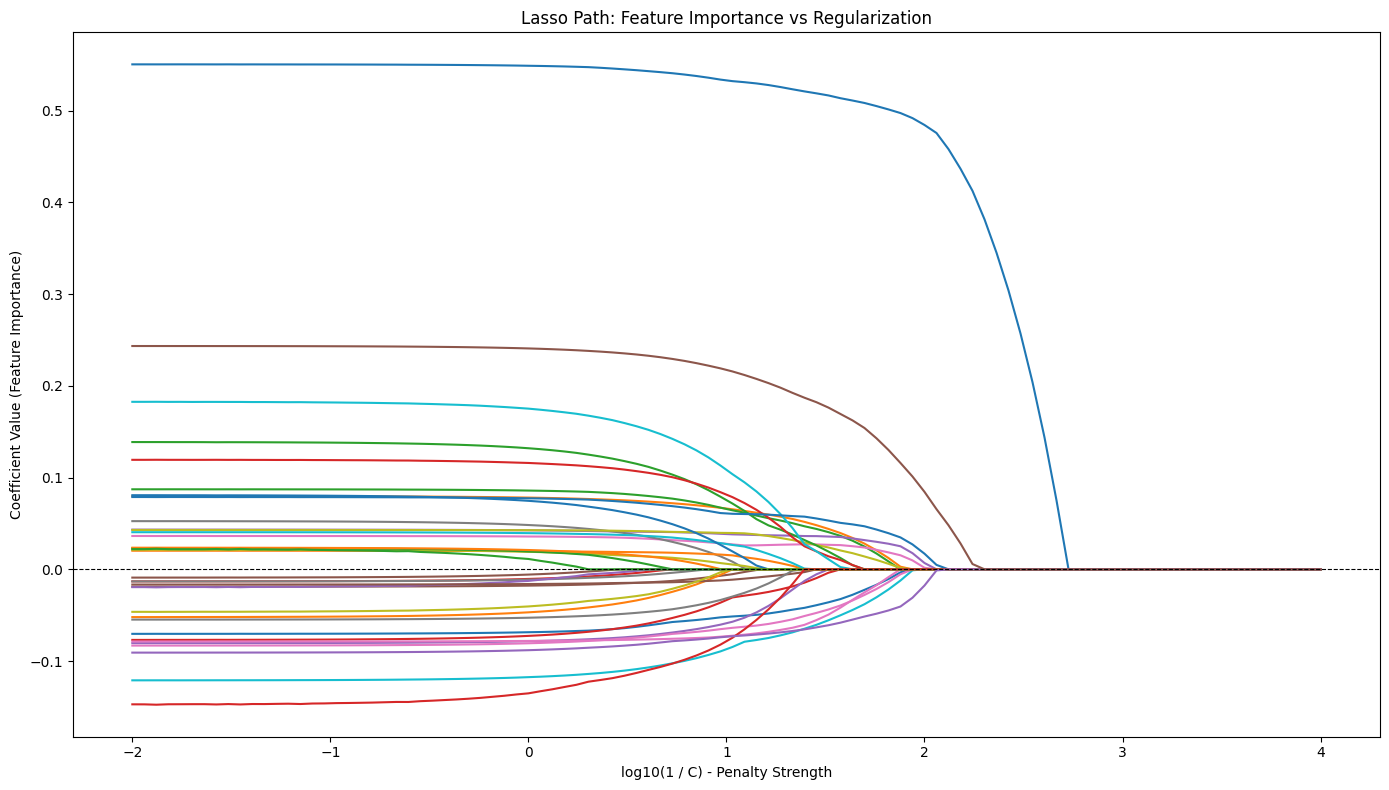

                             vanish_index  rank
proba_fair_open_diff                   78     1
age_blue                               71     2
age_red                                68     3
win_streak_diff                        68     3
ratio_control_red                      67     5
adjusted_td_red                        67     5
ratio_td_blue                          66     7
ratio_td_red                           65     8
ko_losses_red                          65     8
sig_str_absorbed_pm_red                65     8
reach_diff                             65     8
opp_age_red                            64    12
sub_pct_red                            64    12
sig_str_accuracy_pct_red               61    14
sig_str_absorbed_total_blue            61    14
win_pct_blue                           60    16
sig_str_accuracy_pct_blue              59    17
adjusted_sig_str_blue                  58    18
sig_str_absorbed_pm_blue               57    19
kd_pm_diff                             5

In [5]:
coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)


In [17]:

bad_cols = ['proba_fair_open_red', 'proba_fair_open_blue', 'pimp_open_red', 'pimp_open_blue', 'dec_fair_open_red', 'dec_fair_open_blue',
            'dec_open_red', 'dec_open_blue', 'open_red', 'open_blue', 'juice_open_red', 'juice_open_blue', 'elo_red_proba', 'elo_blue_proba',
            'dog_counts_red', 'dog_counts_blue', 'fav_counts_red', 'fav_counts_blue']

non_diff_feats = [ feat for feat in df_model.columns if feat.endswith('_diff') is False]
non_diff_feats = [x for x in non_diff_feats if x not in bad_cols]
y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(non_diff_feats, outlier_dict=None)

Filtered: kept 6650 rows from 2010-02-26 onward.
PREPARE SHAPE: (4256, 297)
MODEL SHAPE: (4177, 297)
Categorical columns: ['math_red', 'math_blue', 'womens_fight']
Numerical columns: ['td_defense_pct_red', 'td_total_attempted_against_red', 'td_total_landed_against_red', 'td_defense_pct_blue', 'td_total_attempted_against_blue', 'td_total_landed_against_blue', 'sig_str_defense_pct_red', 'sig_str_total_attempted_against_red', 'sig_str_total_landed_against_red', 'sig_str_defense_pct_blue', 'sig_str_total_attempted_against_blue', 'sig_str_total_landed_against_blue', 'td_accuracy_pct_red', 'td_accuracy_pct_blue', 'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue', 'kd_pm_red', 'kd_total_red', 'kd_pm_blue', 'kd_total_blue', 'sig_str_landed_pm_red', 'sig_str_landed_total_red', 'sig_str_landed_pm_blue', 'sig_str_landed_total_blue', 'sig_str_absorbed_pm_red', 'sig_str_absorbed_total_red', 'sig_str_absorbed_pm_blue', 'sig_str_absorbed_total_blue', 'sig_str_attempted_pm_red', 'sig_str_attempt

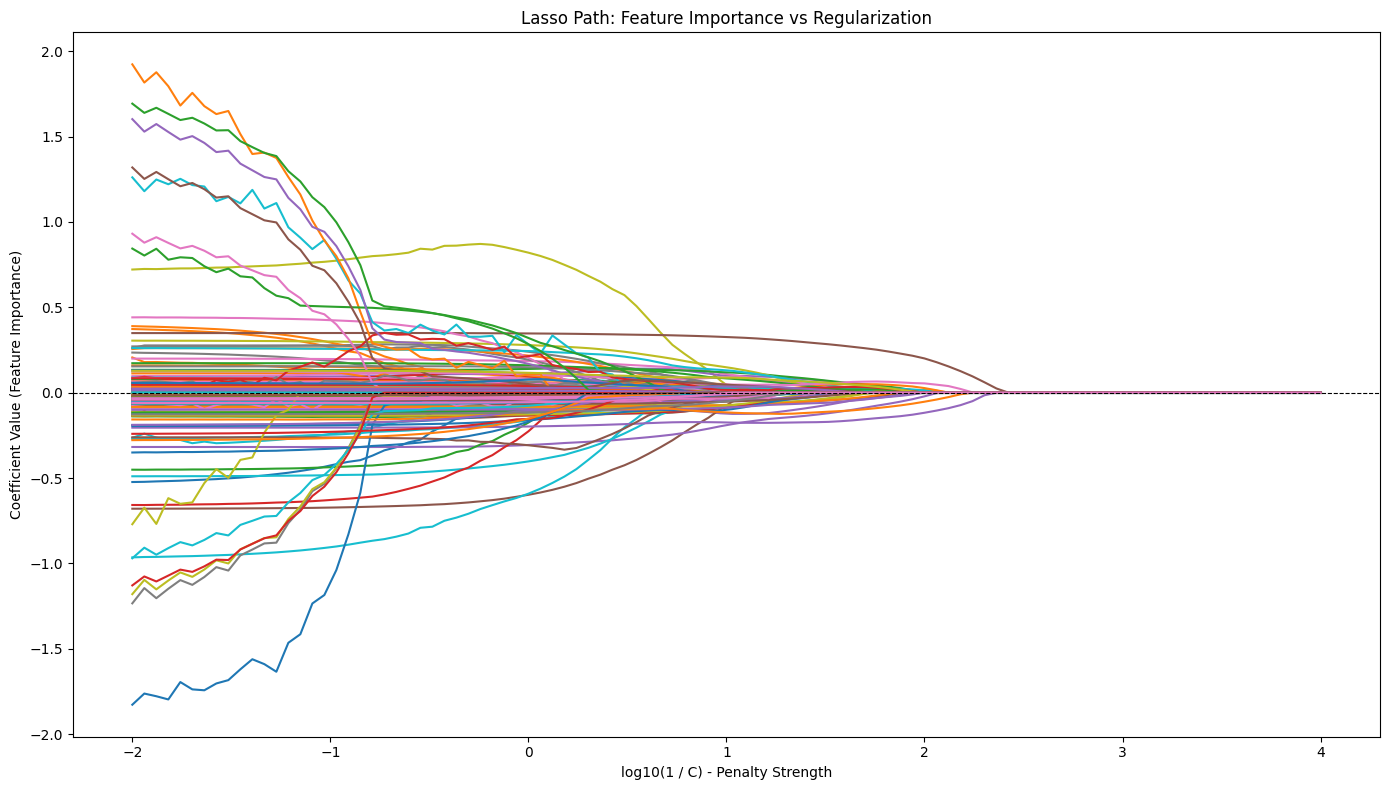

                                      vanish_index  rank
age_blue                                        73     1
age_red                                         72     2
win_pct_red                                     71     3
ko_losses_red                                   70     4
adjusted_td_red                                 68     5
td_attempted_pm_blue                            68     5
elo_pred                                        68     5
td_landed_pm_red                                68     5
ratio_td_red                                    67     9
ratio_control_red                               67     9
td_attempted_pm_red                             67     9
win_streak_red                                  66    12
num_losses_blue                                 66    12
win_streak_blue                                 66    12
sub_pct_red                                     66    12
sig_str_absorbed_pm_red                         66    12
ratio_td_blue                  

In [18]:

coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)


In [ ]:
diff_feats = [ feat for feat in df_model.columns if feat.endswith('_diff')]

y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.85, random_state=42)
builder.filter_by_date(year=2010, month=2, day=26, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test, scaler_open = builder.prepare_train_test(diff_feats, outlier_dict=None)


PREPARE SHAPE: (5118, 290)
MODEL SHAPE: (5030, 59)
Categorical columns: []
Numerical columns: ['kd_total_diff', 'kd_pm_diff', 'sig_str_landed_total_diff', 'sig_str_landed_pm_diff', 'sig_str_absorbed_total_diff', 'sig_str_absorbed_pm_diff', 'sig_str_attempted_total_diff', 'sig_str_attempted_pm_diff', 'leg_str_total_diff', 'leg_str_pm_diff', 'head_str_total_diff', 'head_str_pm_diff', 'body_str_total_diff', 'body_str_pm_diff', 'clinch_str_total_diff', 'clinch_str_pm_diff', 'td_landed_total_diff', 'td_landed_pm_diff', 'td_attempted_total_diff', 'td_attempted_pm_diff', 'control_total_diff', 'control_pm_diff', 'sub_att_total_diff', 'sub_att_pm_diff', 'reverse_total_diff', 'reverse_pm_diff', 'age_diff', 'height_diff', 'reach_diff', 'sig_str_defense_pct_diff', 'sig_str_accuracy_pct_diff', 'td_accuracy_pct_diff', 'td_defense_pct_diff', 'avg_fight_min_diff', 'total_bonus_diff', 'elo_diff', 'glicko_diff', 'months_since_diff', 'num_fights_diff', 'win_streak_diff', 'lose_streak_diff', 'wins_diff', 

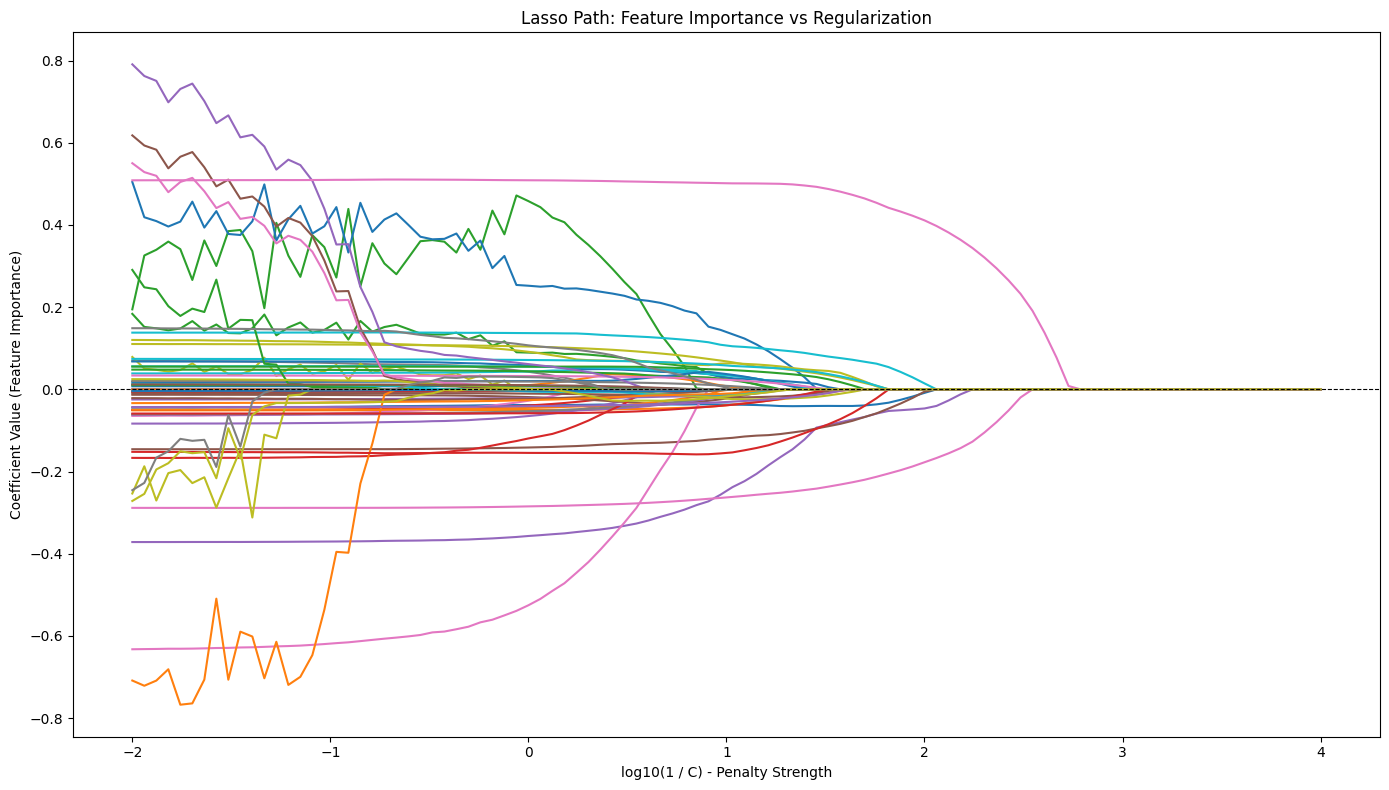

                              vanish_index  rank
proba_fair_open_diff                    79     1
age_diff                                75     2
sig_str_absorbed_total_diff             70     3
sig_str_absorbed_pm_diff                67     4
td_attempted_pm_diff                    67     4
kd_total_diff                           67     4
win_pct_diff                            64     7
reach_diff                              64     7
td_attempted_total_diff                 63     9
win_streak_diff                         63     9
td_defense_pct_diff                     62    11
ko_losses_diff                          62    11
ratio_control_diff                      60    13
kd_pm_diff                              60    13
reverse_pm_diff                         59    15
control_total_diff                      59    15
glicko_diff                             58    17
ratio_td_diff                           58    17
head_str_total_diff                     58    17
sig_str_defense_pct_

In [ ]:

coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)
print(rank_df)


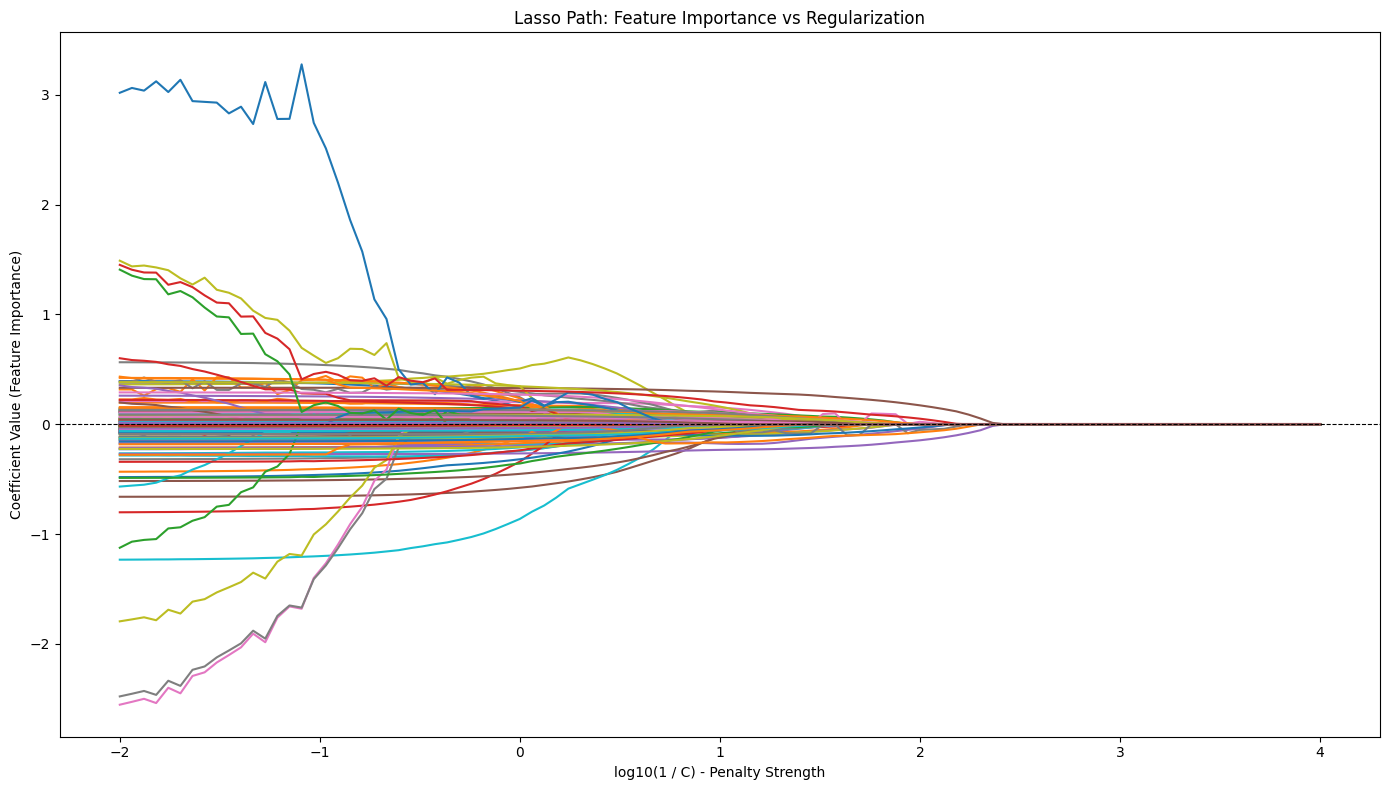

                           vanish_index  rank
age_blue                             73     1
age_red                              73     1
dog_counts_red                       72     3
elo_red_proba                        70     4
dog_counts_blue                      70     4
...                                 ...   ...
sig_str_landed_total_blue             7   162
sig_str_landed_pm_red                 3   163
num_fights_red                        2   164
blue_title_wins                       0   165
red_title_fights                      0   165

[166 rows x 2 columns]


In [ ]:


coef_df = plot_lasso_path(X_train, y_train, C_min=1e-4, C_max=1e2, num_C=num_C, figsize=(14,8))
rank_df = rank_features_by_lasso_path(coef_df, C_values)
print(rank_df)

In [53]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None):
    print(rank_df)

                                      vanish_index  rank
age_blue                                        73     1
age_red                                         73     1
dog_counts_red                                  72     3
elo_red_proba                                   70     4
dog_counts_blue                                 70     4
elo_blue_proba                                  70     4
sig_str_absorbed_pm_red                         69     7
ko_losses_red                                   69     7
td_landed_pm_red                                67     9
sub_pct_red                                     66    10
td_attempted_pm_red                             66    10
reverse_pm_red                                  65    12
td_attempted_pm_blue                            65    12
elo_pred                                        65    12
sig_str_accuracy_pct_red                        64    15
max_elo_win_blue                                63    16
ratio_control_red              

In [6]:
rank_df.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\models\lr_stats_save\lass_reg_results.csv')

Confusion matrix:
 [[229 140]
 [185 294]]

Accuracy: 0.6167

Classification report:
               precision    recall  f1-score   support

         0.0       0.55      0.62      0.58       369
         1.0       0.68      0.61      0.64       479

    accuracy                           0.62       848
   macro avg       0.62      0.62      0.61       848
weighted avg       0.62      0.62      0.62       848



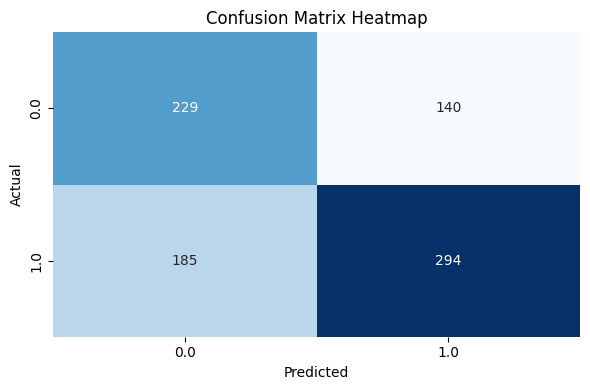

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# probs 
probs_2d = model.predict_proba(X_test)

# 5. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# 6. Accuracy & report
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

# 7. Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

In [60]:
test_answers = pd.DataFrame()


test_answers['blue_probs'] = probs_2d[:,0]
test_answers['red_probs'] = probs_2d[:,1]
test_answers['pred_winner'] = np.argmax(probs_2d, axis=1)

test_answers['winner'] = copy_df.iloc[train_len:]['winner'].reset_index(drop=True)
# test_answers['winner'] = y_test.reset_index(drop=True)
test_answers['correct_pred'] = (test_answers['pred_winner'] == test_answers['winner']).astype(int)
test_answers['event_dates'] = copy_df.iloc[train_len:]['date'].reset_index(drop=True)

test_answers['open_red'] = copy_df.iloc[train_len:]['open_red'].reset_index(drop=True)
test_answers['open_blue'] = copy_df.iloc[train_len:]['open_blue'].reset_index(drop=True)
test_answers['event_dates'] = copy_df.iloc[train_len:]['date'].reset_index(drop=True)
test_answers['red_fighter'] = copy_df.iloc[train_len:]['red_fighter'].reset_index(drop=True)
test_answers['blue_fighter'] = copy_df.iloc[train_len:]['blue_fighter'].reset_index(drop=True)

test_answers.info()
print(test_answers.info())

test_answers.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results_v2.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   blue_probs    751 non-null    float64
 1   red_probs     751 non-null    float64
 2   pred_winner   751 non-null    int64  
 3   winner        751 non-null    int64  
 4   correct_pred  751 non-null    int64  
 5   event_dates   751 non-null    object 
 6   open_red      751 non-null    float64
 7   open_blue     751 non-null    float64
 8   red_fighter   751 non-null    object 
 9   blue_fighter  751 non-null    object 
dtypes: float64(4), int64(3), object(3)
memory usage: 58.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   blue_probs    751 non-null    float64
 1   red_probs     751 non-null    float64
 2   pred_winner   751 non-null    int6